# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving patient_demographics.csv to patient_demographics.csv
Saving lifestyle_factors.csv to lifestyle_factors.csv
Saving clinical_data.csv to clinical_data.csv


In [3]:
# Load datasets
demographics = pd.read_csv("/content/patient_demographics.csv")
clinical = pd.read_csv("/content/clinical_data.csv")
lifestyle = pd.read_csv("/content/lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [4]:
#your code here
demographics.head()



,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


In [5]:
clinical.head()


,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


In [6]:
lifestyle.head()

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


In [7]:
#your code here
demographics.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Country     8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB


In [8]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


In [9]:
lifestyle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   object 
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 547.8+ KB


In [10]:
#your code here
demographics.describe()


,Age,Income
count,8763.000000,8763.000000
mean,53.707977,158263.181901
std,21.249509,80575.190806
min,18.000000,20062.000000
25%,35.000000,88310.000000
50%,54.000000,157866.000000
75%,72.000000,227749.000000
max,90.000000,299954.000000


In [11]:
clinical.describe()


,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211


In [12]:
lifestyle.describe()

,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Stress Level,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,0.896839,0.501426,0.598083,10.014284,5.469702,0.358211
std,0.304186,0.500026,0.490313,5.783745,2.859622,0.479502
min,0.000000,0.000000,0.000000,0.002442,1.000000,0.000000
25%,1.000000,0.000000,0.000000,4.981579,3.000000,0.000000
50%,1.000000,1.000000,1.000000,10.069559,5.000000,0.000000
75%,1.000000,1.000000,1.000000,15.050018,8.000000,1.000000
max,1.000000,1.000000,1.000000,19.998709,10.000000,1.000000


In [13]:
demographics.isnull().sum()

,0
Patient ID,0
Age,0
Sex,0
Income,0
Country,0
Continent,0
Hemisphere,0


In [14]:
clinical.isnull().sum()

,0
Patient ID,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Triglycerides,0
BMI,0


In [15]:
lifestyle.isnull().sum()

,0
Patient ID,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Diet,0
Stress Level,0
Heart Attack Risk,0


## Data Assessment Summary

### Demographics Data Assessment
- No missing values across all columns.
- Data types are appropriate:
  - Numerical columns (e.g., `Age`, `Income`) are `int64`.
  - Categorical/identifier columns are `object`.
- No obvious data quality issues found.

### Clinical Data Assessment
- No missing values across all columns.
- Issue identified:
  - `Blood Pressure` is stored as `object` in `Systolic/Diastolic` format (e.g., `120/80`).
- This format is unsuitable for numerical analysis.
- Recommended fix:
  - Split into two separate numerical columns:
    - `Systolic BP`
    - `Diastolic BP`
- All other columns have appropriate data types.

### Lifestyle Data Assessment
- No missing values across all columns.
- Data types are appropriate:
  - `Exercise Hours Per Week` → `float64`
  - Binary columns (e.g., `Smoking`, `Heart Attack Risk`, `Stress Level`) → `int64`
  - `Diet` → `object`
- Binary columns stored as `int64` are acceptable since they represent `0` and `1`.
- No obvious data quality issues found.

# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [16]:
clinical['Blood Pressure'].head(10)

,Blood Pressure
0,158/88
1,165/93
2,174/99
3,163/100
4,91/88
5,172/86
6,102/73
7,131/68
8,144/105
9,160/70


In [17]:
#your code here
clinical['Blood Pressure'].dtype

dtype('O')

In pandas, dtype('O') means the column has the object data type.

In [18]:
#your code here
clinical['Blood Pressure'].mean()


TypeError: Could not convert string '...' to numeric

The TypeError: Could not convert string ... to numeric occurs because the Blood Pressure column in your clinical DataFrame is currently stored as an object (string) data type, as indicated by clinical['Blood Pressure'].dtype which returned dtype('O'). The mean() function expects numerical values to perform its calculation. Since the column contains strings in the format 'Systolic/Diastolic' (e.g., '158/88'), pandas cannot directly convert these textual representations into numbers to compute an average. To fix this, you first need to split this column into two separate numerical columns for Systolic and Diastolic blood pressure, and then convert those new columns to a numeric data type.

In [19]:
#your code here
clinical[['Systolic BP', 'Diastolic BP']] = clinical['Blood Pressure'].str.split('/', expand=True).astype(int)
clinical.head()

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic BP,Diastolic BP
0,BMW7812,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,318,91/88,93,1,1,231,21.809144,91,88


In [20]:
print("Systolic Mean =", clinical['Systolic BP'].mean())
print("Diastolic Mean =", clinical['Diastolic BP'].mean())

Systolic Mean = 135.07565902088325
Diastolic Mean = 85.1561109209175


## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [21]:
#your code here
clinical.isnull().sum()

,0
Patient ID,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Triglycerides,0
BMI,0
Systolic BP,0
Diastolic BP,0


In [22]:
#your code here
lifestyle.isnull().sum()

,0
Patient ID,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Diet,0
Stress Level,0
Heart Attack Risk,0


In [23]:
#your code here
demographics.isnull().sum()

,0
Patient ID,0
Age,0
Sex,0
Income,0
Country,0
Continent,0
Hemisphere,0


Every column shows 0, which means there are no missing (NaN) values anywhere in your lifestyle DataFrame in pandas.

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


In [24]:
#your code here
#As the data Age, Cholesterol, BMI are on seperate dataframe we need to merge it

merged_dataframe = demographics.merge(clinical, on='Patient ID')
merged_dataframe.head()

#This is similar to SQL join

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic BP,Diastolic BP
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere,208,158/88,72,0,0,286,31.251233,158,88
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere,389,165/93,98,1,1,235,27.194973,165,93
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere,324,174/99,72,1,0,587,28.176571,174,99
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere,383,163/100,73,1,1,378,36.464704,163,100
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere,318,91/88,93,1,1,231,21.809144,91,88


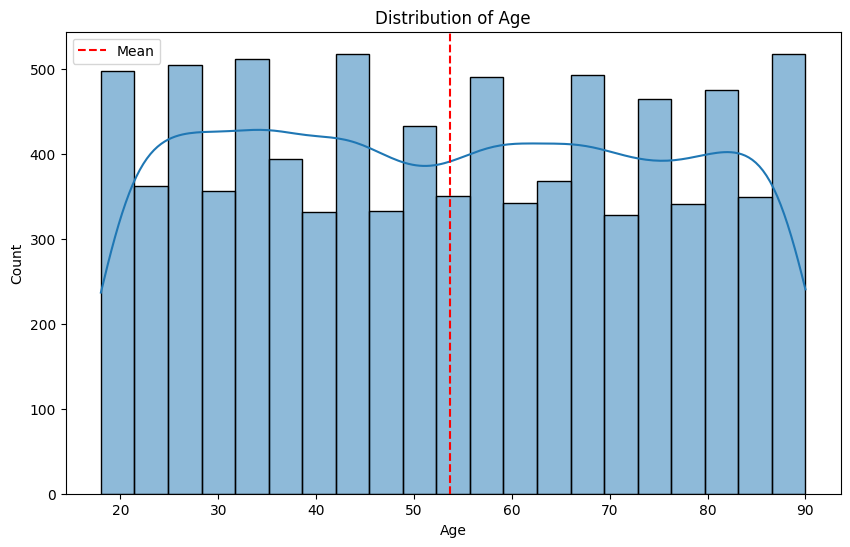

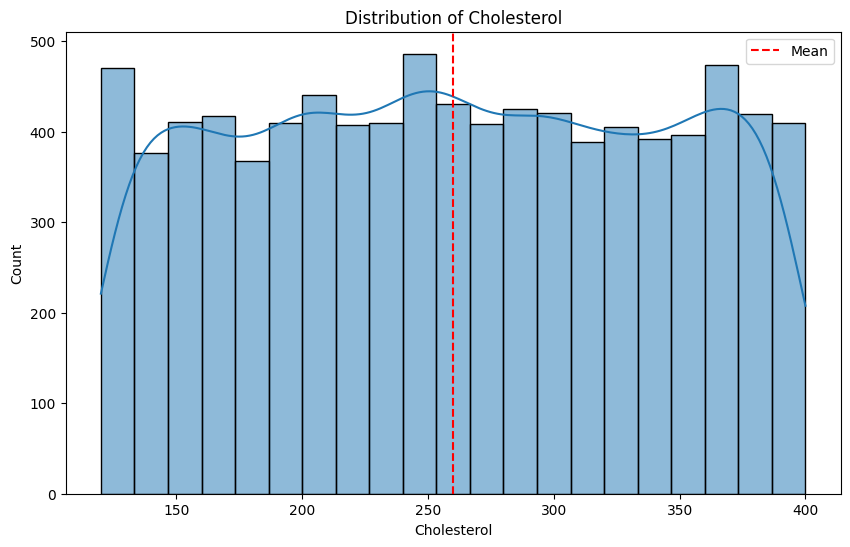

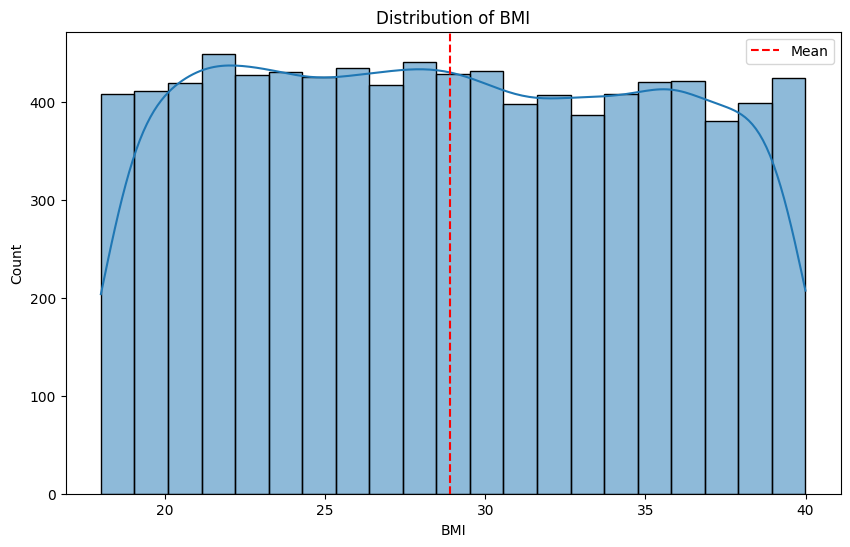

In [25]:
#Syntax : sns.histplot(data=df, x='Age', kde=True)
#plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')

cols = ['Age', 'Cholesterol', 'BMI']

for col in cols:
  plt.figure(figsize=(10,6))
  sns.histplot(data=merged_dataframe, x = col, kde=True)
  plt.axvline(merged_dataframe[col].mean(), color='red', linestyle='--',label = 'Mean')
  plt.title(f'Distribution of {col}')
  plt.legend()
  plt.show()

In [26]:
#Skewness
for col in cols:
  skewness = merged_dataframe[col].skew()
  print(f'The skewness of {col} column is {skewness:.2f}')

The skewness of Age column is 0.03
The skewness of Cholesterol column is -0.00
The skewness of BMI column is 0.04


No transformations is required as data is already symmetric.

In [27]:
#Check for spikes
for col in cols:
  print(f"\nTop values in {col}:")
  print(merged_dataframe[col].value_counts().head(5))


Top values in Age:
Age
90    152
42    150
33    147
59    147
29    137
Name: count, dtype: int64

Top values in Cholesterol:
Cholesterol
235    52
360    47
218    46
149    46
251    45
Name: count, dtype: int64

Top values in BMI:
BMI
32.914151    1
31.251233    1
27.194973    1
28.176571    1
36.464704    1
Name: count, dtype: int64


In [28]:
# Even though shape is fine, scale may differ.
print('Before Scaling')
merged_dataframe.describe()

Before Scaling


,Age,Income,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic BP,Diastolic BP
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,158263.181901,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446,135.075659,85.156111
std,21.249509,80575.190806,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181,26.349976,14.676565
min,18.000000,20062.000000,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337,90.000000,60.000000
25%,35.000000,88310.000000,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985,112.000000,72.000000
50%,54.000000,157866.000000,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999,135.000000,85.000000
75%,72.000000,227749.000000,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594,158.000000,98.000000
max,90.000000,299954.000000,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211,180.000000,110.000000


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

merged_dataframe[cols] = scaler.fit_transform(
    merged_dataframe[cols]
)

print('After Scaling')
merged_dataframe.describe()


After Scaling


,Age,Income,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,Systolic BP,Diastolic BP
count,8.763000e+03,8763.000000,8.763000e+03,8763.000000,8763.000000,8763.000000,8763.000000,8.763000e+03,8763.000000,8763.000000
mean,-5.756994e-17,158263.181901,5.594825e-17,75.021682,0.652288,0.492982,417.677051,-3.389329e-16,135.075659,85.156111
std,1.000057e+00,80575.190806,1.000057e+00,20.550948,0.476271,0.499979,223.748137,1.000057e+00,26.349976,14.676565
min,-1.680510e+00,20062.000000,-1.729898e+00,40.000000,0.000000,0.000000,30.000000,-1.723282e+00,90.000000,60.000000
25%,-8.804460e-01,88310.000000,-8.394550e-01,57.000000,0.000000,0.000000,225.500000,-8.654242e-01,112.000000,72.000000
50%,1.374337e-02,157866.000000,-1.084870e-02,75.000000,1.000000,0.000000,417.000000,-1.937807e-02,135.000000,85.000000
75%,8.608701e-01,227749.000000,8.672267e-01,93.000000,1.000000,1.000000,612.000000,8.598357e-01,158.000000,98.000000
max,1.707997e+00,299954.000000,1.732935e+00,110.000000,1.000000,1.000000,800.000000,1.757569e+00,180.000000,110.000000


## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

In [30]:
#For this we will merge all three tables
merged_all = demographics.merge(clinical, on='Patient ID').merge(lifestyle, on='Patient ID')
merged_all.head().T

,0,1,2,3,4
Patient ID,BMW7812,CZE1114,BNI9906,JLN3497,GFO8847
Age,67,21,21,84,66
Sex,Male,Male,Female,Male,Male
Income,261404,285768,235282,125640,160555
Country,Argentina,Canada,France,Canada,Thailand
Continent,South America,North America,Europe,North America,Asia
Hemisphere,Southern Hemisphere,Northern Hemisphere,Northern Hemisphere,Northern Hemisphere,Northern Hemisphere
Cholesterol,208,389,324,383,318
Blood Pressure,158/88,165/93,174/99,163/100,91/88
Heart Rate,72,98,72,73,93


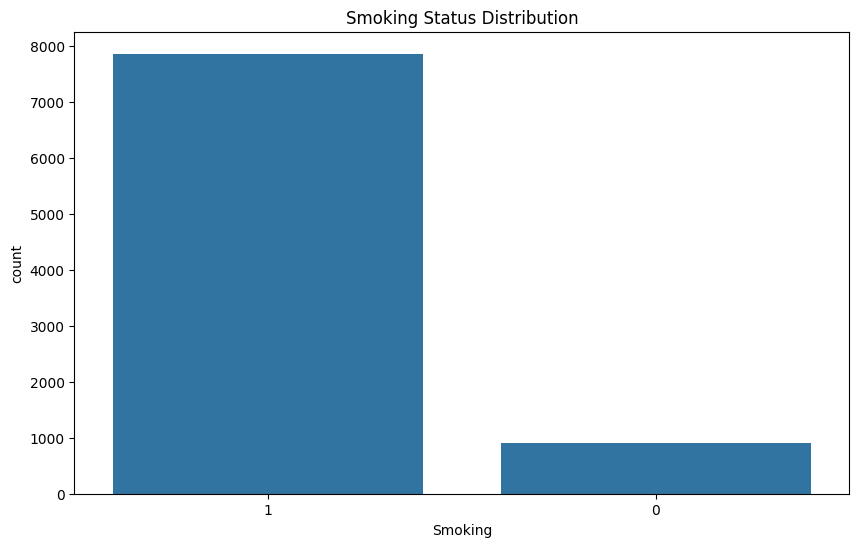

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(data=merged_all, x = 'Smoking', order = merged_all['Smoking'].value_counts().index)

plt.title("Smoking Status Distribution")
plt.show()

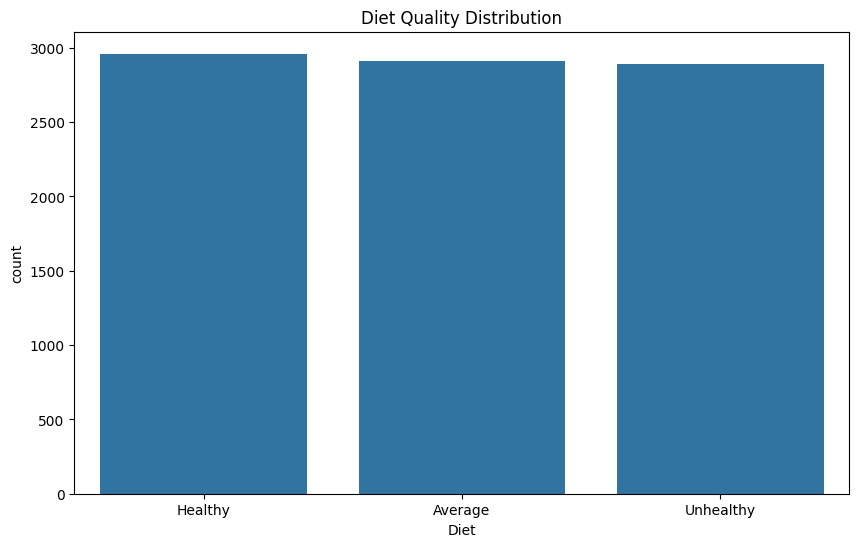

In [32]:
# Diet Quality distribution
plt.figure(figsize=(10,6))
sns.countplot(data = merged_all, x = 'Diet', order=merged_all['Diet'].value_counts().index)

plt.title("Diet Quality Distribution")
plt.show()

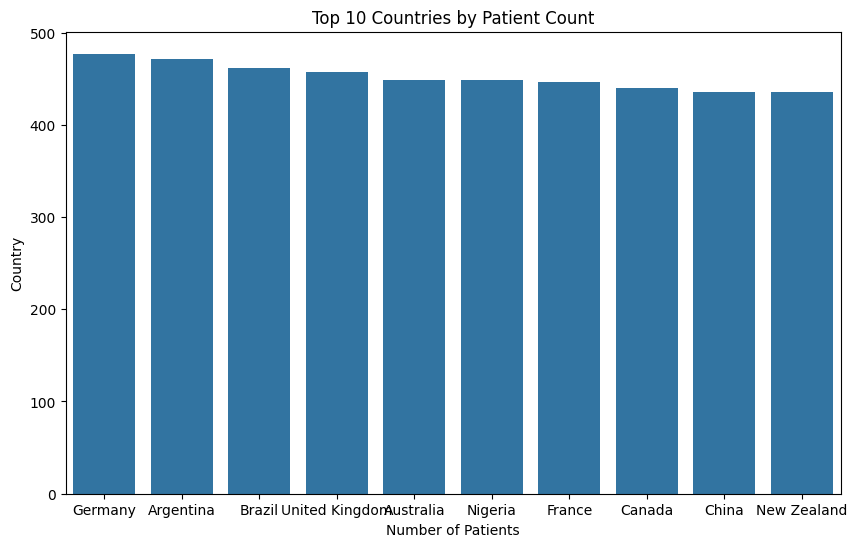

In [33]:
top_countries = merged_all['Country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Patient Count")
plt.xlabel("Number of Patients")
plt.ylabel("Country")
plt.show()

In [34]:
merged_all['Smoking'].value_counts(normalize=True) * 100

,proportion
Smoking,
1,89.683898
0,10.316102


What proportion of patients smoke?

=> 89.683898

Which diet category is most common?

=> Healthy Diet

Which countries are most represented?

=>Germany

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

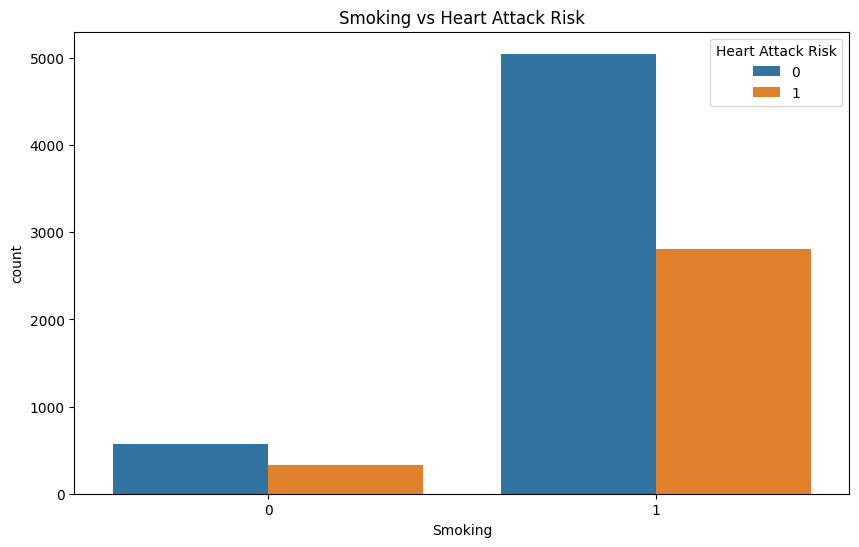

In [44]:
#your code here
plt.figure(figsize = (10,6))
sns.countplot(data = merged_all, x = 'Smoking', hue='Heart Attack Risk')
plt.title("Smoking vs Heart Attack Risk")
plt.show()


In [50]:
merged_all.groupby('Smoking')['Heart Attack Risk'].mean()*100

,Heart Attack Risk
Smoking,
0,36.393805
1,35.755185


Do smokers show noticeably higher risk counts?
No — and this is the most striking finding. Despite smokers making up the overwhelming majority of this dataset their risk rate is actually marginally lower (35.76%) than non-smokers (36.39%). The raw count difference is simply a reflection of the group size imbalance, not a meaningful signal.

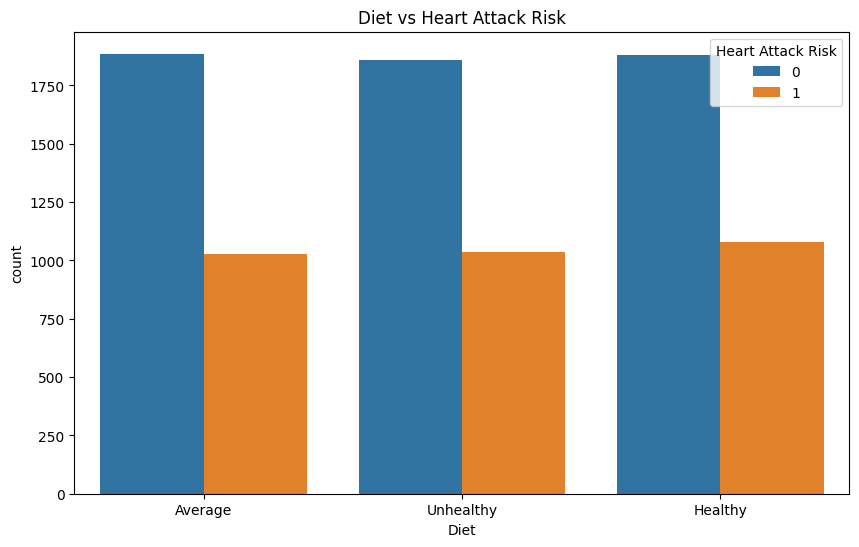

In [46]:
plt.figure(figsize = (10,6))
sns.countplot(data = merged_all , x = 'Diet', hue = 'Heart Attack Risk')
plt.title("Diet vs Heart Attack Risk")
plt.show()

In [52]:
merged_all.groupby('Diet')['Heart Attack Risk'].mean()*100

,Heart Attack Risk
Diet,
Average,35.233516
Healthy,36.452703
Unhealthy,35.766171


Does diet quality appear protective against heart attack risk?
No. The risk rates are essentially flat across all three diet groups — Healthy (36.45%), Unhealthy (35.77%), and Average (35.23%). Counterintuitively, the "Healthy" diet group has the highest risk rate of the three, which strongly suggests diet is not a meaningful predictor in this dataset on its own.

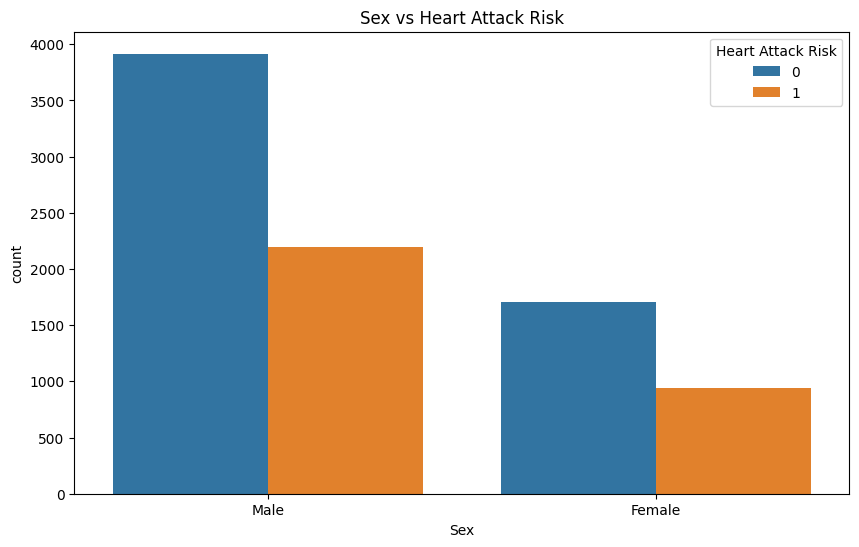

In [47]:
plt.figure(figsize = (10,6))
sns.countplot(data = merged_all , x = 'Sex', hue = 'Heart Attack Risk')
plt.title("Sex vs Heart Attack Risk")
plt.show()


In [53]:
merged_all.groupby('Sex')['Heart Attack Risk'].mean()*100

,Heart Attack Risk
Sex,
Female,35.595777
Male,35.918835


Is there a difference in risk between male and female patients?
Effectively no. Males show a 35.92% risk rate vs females at 35.60% — a difference of just 0.32 percentage points.

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [60]:
#your code here
numeric_cols = merged_all.select_dtypes(include=['int64','float']).columns
numeric_cols



Index(['Age', 'Income', 'Cholesterol', 'Heart Rate', 'Diabetes',
       'Family History', 'Triglycerides', 'BMI', 'Systolic BP', 'Diastolic BP',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Stress Level', 'Heart Attack Risk'],
      dtype='object')

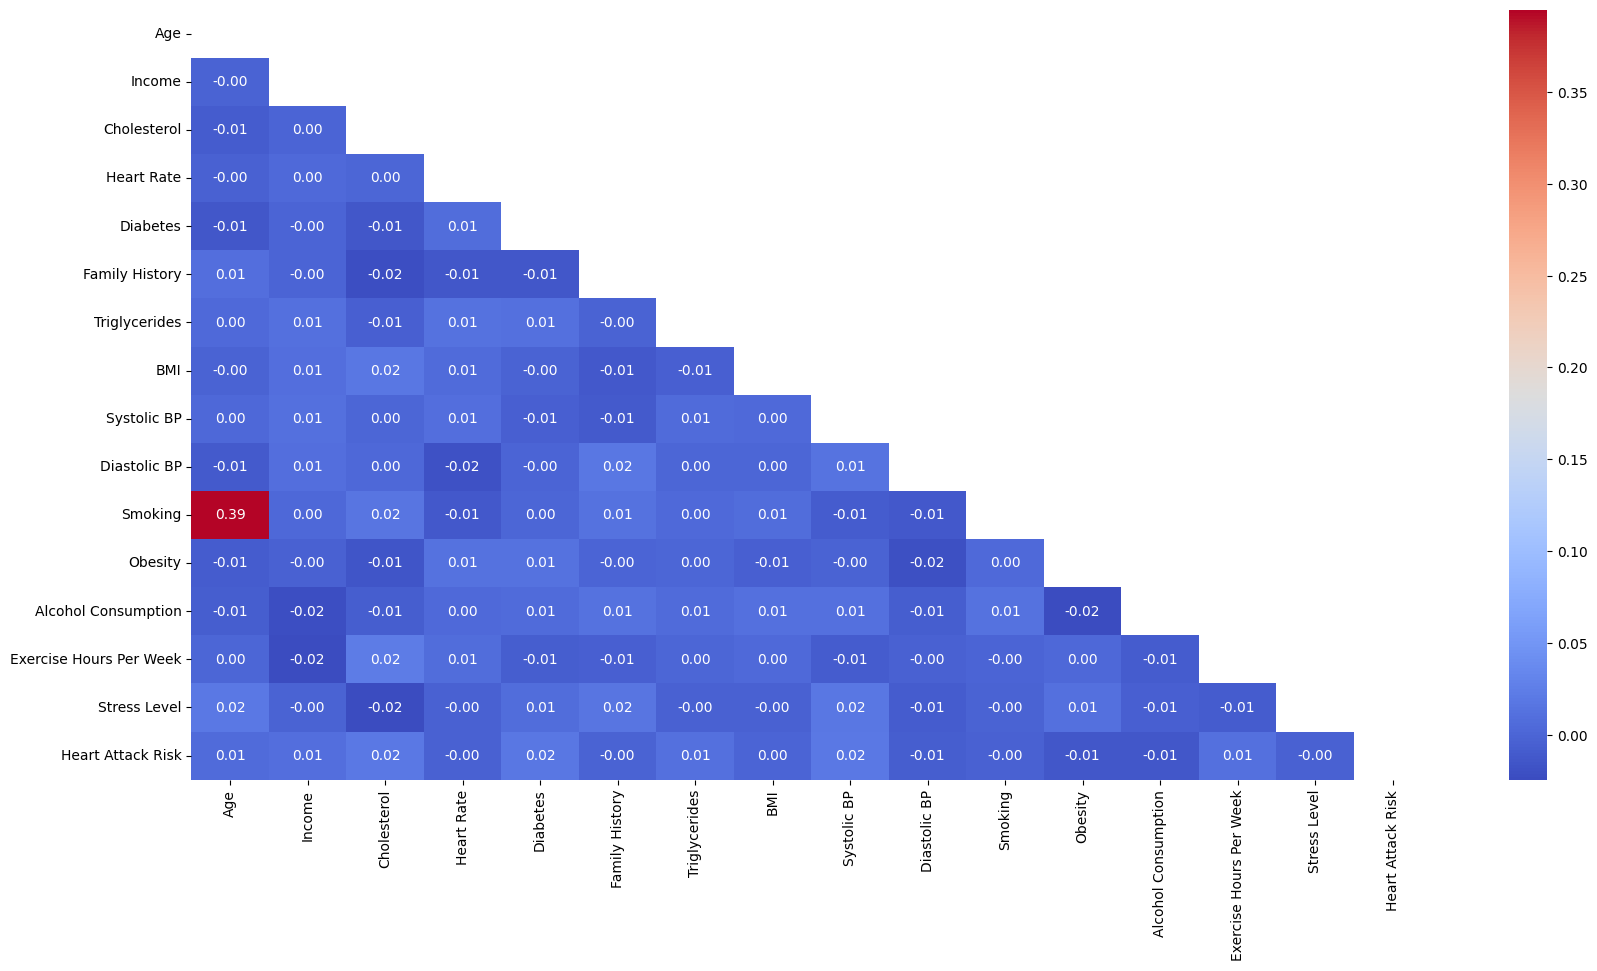

In [71]:
corr_matrix = merged_all[numeric_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20,10))

sns.heatmap(corr_matrix, mask = mask, annot = True, cmap='coolwarm', fmt = '.2f')
plt.show()


In [72]:
corr_matrix['Heart Attack Risk'].sort_values(ascending=False)

,Heart Attack Risk
Heart Attack Risk,1.000000
Cholesterol,0.019340
Systolic BP,0.018585
Diabetes,0.017225
Exercise Hours Per Week,0.011133
Triglycerides,0.010471
Income,0.009628
Age,0.006403
BMI,0.000020
Family History,-0.001652


In [77]:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1]
corr_pairs.sort_values(ascending=False).head(10)


Age                      Smoking                    0.394891
Smoking                  Age                        0.394891
Exercise Hours Per Week  Cholesterol                0.021517
Cholesterol              Exercise Hours Per Week    0.021517
                         Heart Attack Risk          0.019340
Heart Attack Risk        Cholesterol                0.019340
Systolic BP              Heart Attack Risk          0.018585
Heart Attack Risk        Systolic BP                0.018585
Stress Level             Age                        0.018307
Age                      Stress Level               0.018307
dtype: float64

In [78]:
corr_pairs = corr_matrix.unstack()
pair = corr_pairs[('Systolic BP','Diastolic BP')]
pair

np.float64(0.01333700929823929)

## Correlation Analysis

### 1. Which feature has the highest correlation with Heart Attack Risk?
- **Cholesterol** shows the highest correlation at **+0.0193**, followed by:
  - **Systolic BP**: +0.0186  
  - **Diabetes**: +0.0172  

- **Interpretation:**  
  These are technically the "strongest" correlations, but all values are extremely close to zero.  
  This indicates:
  - No feature has a meaningful linear relationship with heart attack risk.
  - The dataset may be **synthetic**, with risk assigned randomly, or  
  - The outcome depends on **complex interactions** between features rather than individual variables.

---

### 2. Are any features highly correlated with each other (multicollinearity)?
- The highest observed correlation:
  - **Age ↔ Smoking**: **r = +0.39**

- **Interpretation:**  
  This represents a **moderate correlation**, not strong enough to indicate serious multicollinearity concerns.

---

### 3. Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?
- Observed correlation:
  - **r = +0.0133** (approximately zero)

- **Interpretation:**  
  - In real-world data, systolic and diastolic blood pressure are typically **strongly correlated** due to underlying physiological relationships.
  - The near-zero correlation here suggests:
    - Blood pressure values were likely generated **independently at random**.
    - This further supports the idea that the dataset is **synthetic** and does not preserve real physiological patterns.

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

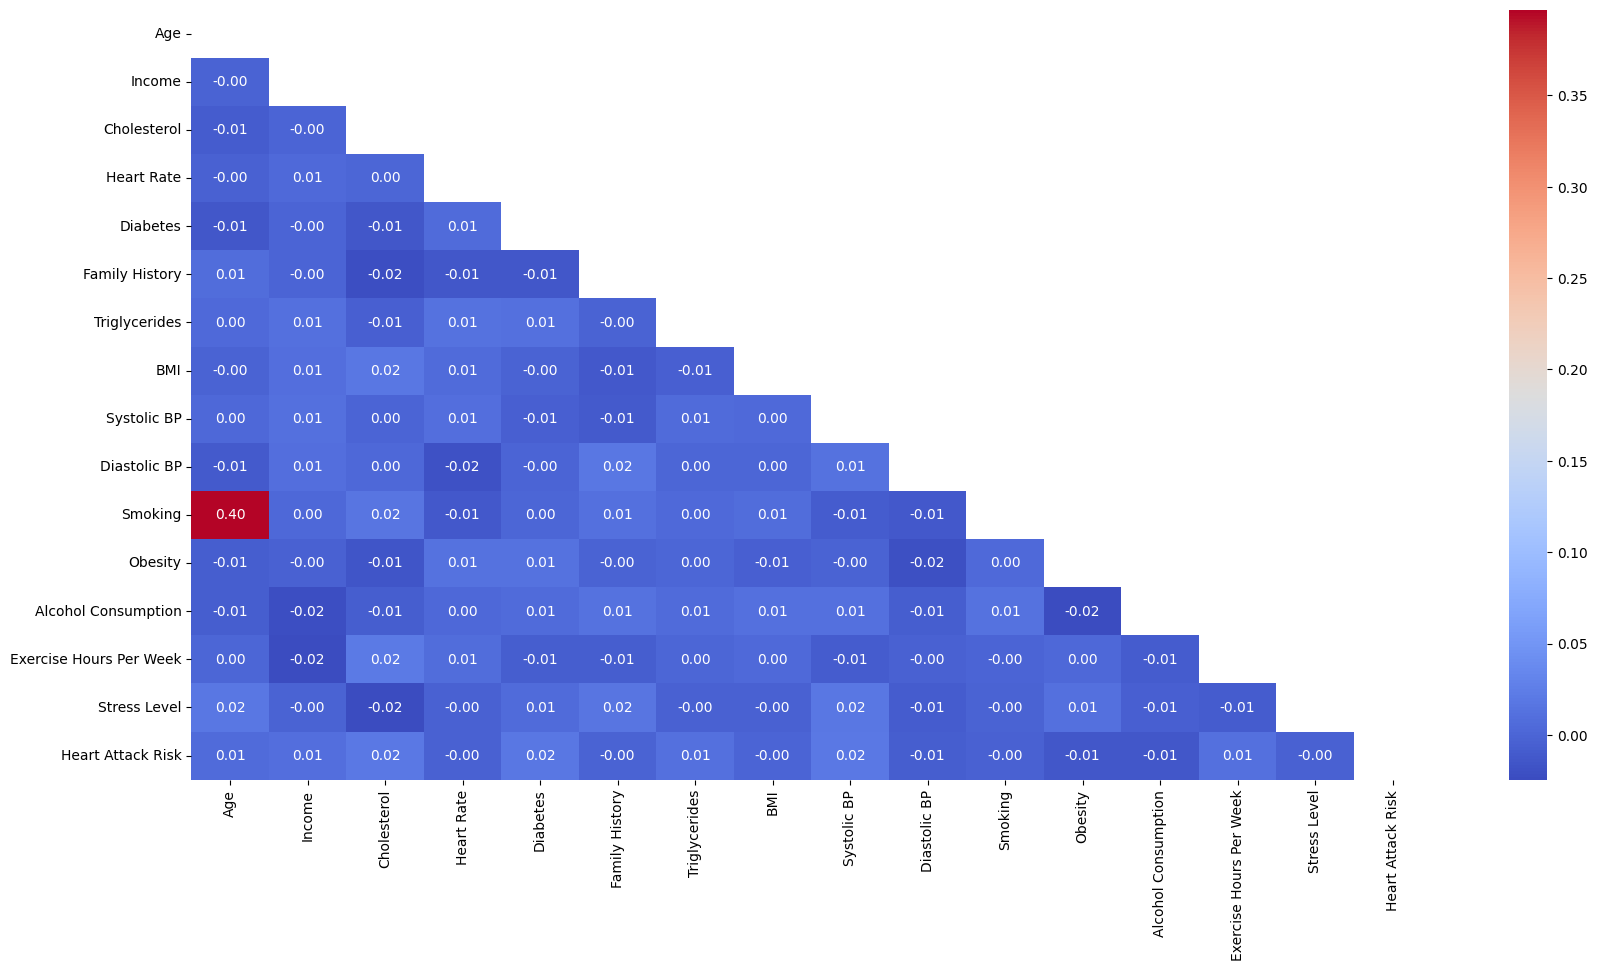

In [79]:
#your code here
corr_matrix = merged_all[numeric_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix,dtype = bool))
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, mask = mask, annot = True, cmap='coolwarm', fmt = '.2f')
plt.show()

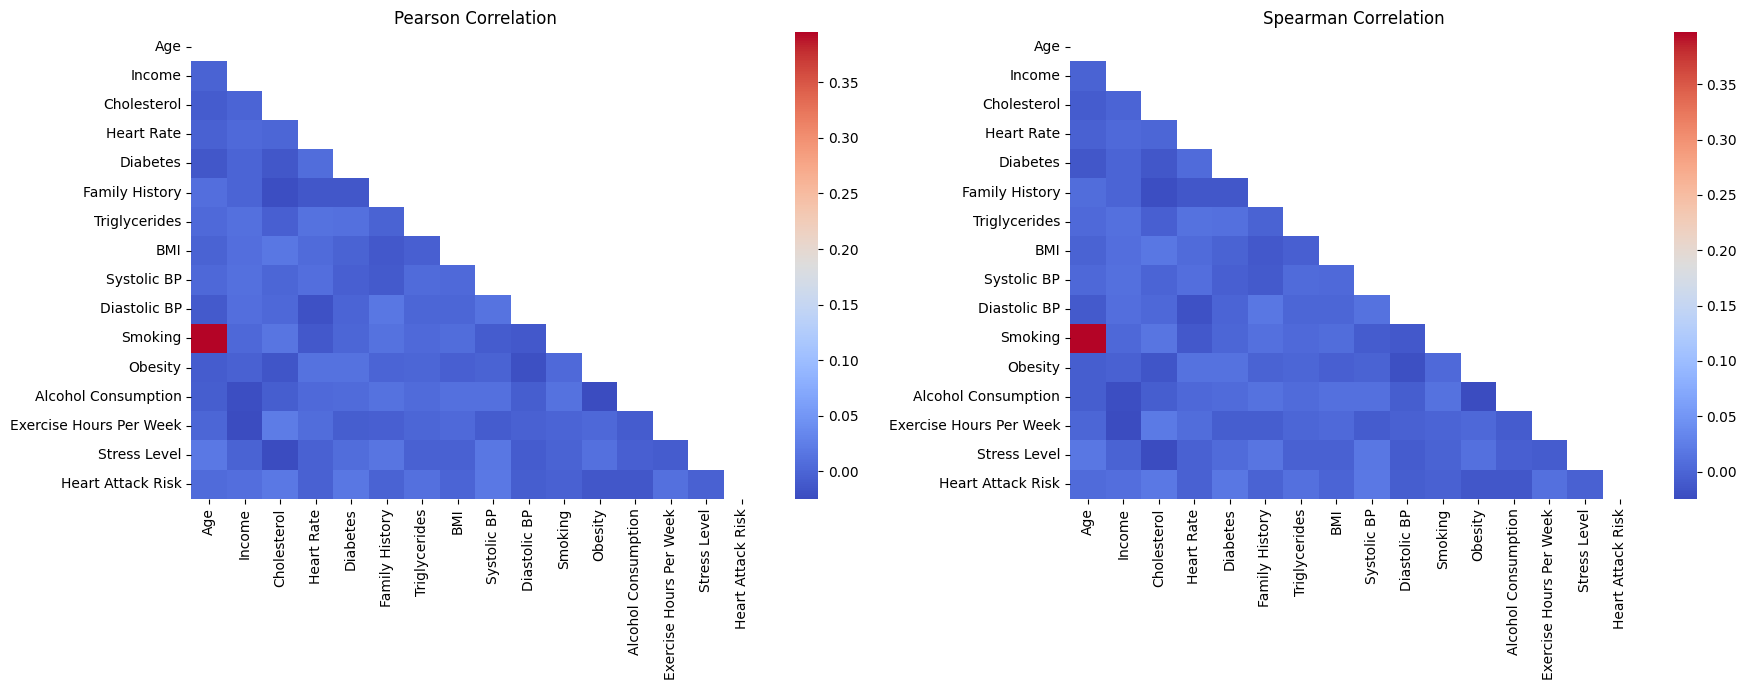

In [84]:
spearman_corr = merged_all[numeric_cols].corr(method='spearman')
pearson_corr = merged_all[numeric_cols].corr(method='pearson')

# Side-by-side heatmaps
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(18,7))

sns.heatmap(
    pearson_corr,
    mask=mask,
    cmap='coolwarm',
    annot=False,
    ax=axes[0]
)
axes[0].set_title("Pearson Correlation")

sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap='coolwarm',
    annot=False,
    ax=axes[1]
)
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

<Axes: >

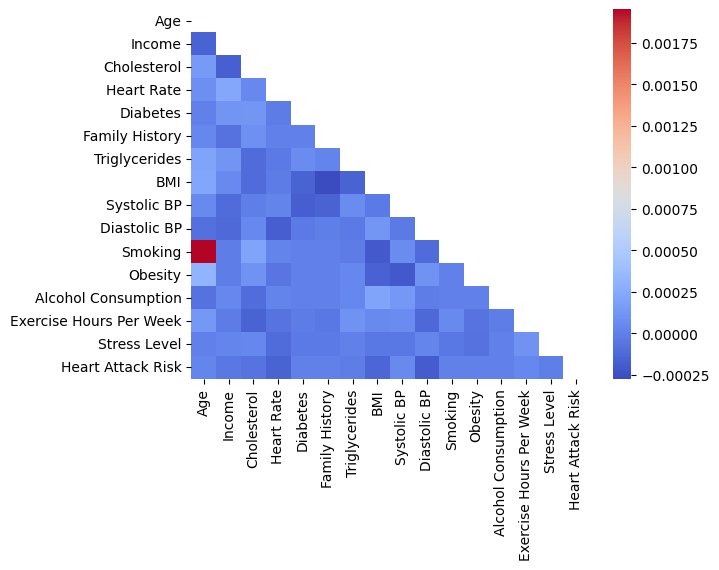

In [85]:
sns.heatmap(spearman_corr - pearson_corr, mask=mask, cmap='coolwarm', annot=False, )

## Pearson vs Spearman Correlation Analysis

### 1. Are the Spearman results significantly different from Pearson?
- **No.**  
  The rankings and overall conclusions are consistent across both methods.

---

### 2. What does this suggest about linearity and outliers?
- **Interpretation:**
  - Spearman correlation is rank-based and more robust to:
    - Non-linear (monotonic) relationships  
    - Outliers that can skew Pearson correlation  

- Since both methods produce nearly identical results, this indicates:

  - **No significant outlier influence**  
    Extreme values are not distorting the correlations. If they were, Spearman (which uses ranks) would differ from Pearson.

  - **No hidden monotonic relationships**  
    If a feature had a non-linear but consistent relationship with the target, Spearman correlation would likely be stronger than Pearson. This is not observed.

  - **Near-zero correlations are reliable**  
    The weak correlations are genuine and not caused by skewed distributions or a few influential data points masking underlying trends.

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


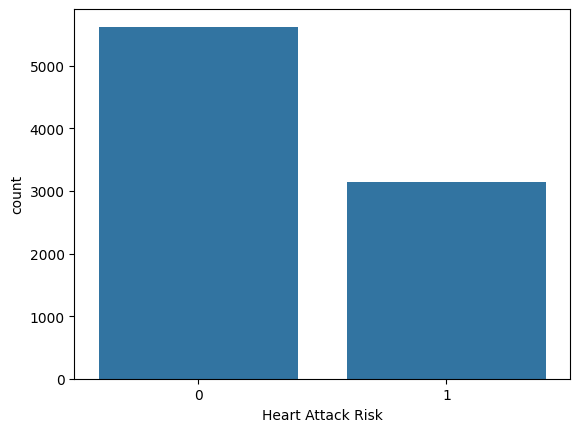

In [89]:
#your code here
sns.countplot(data=merged_all, x='Heart Attack Risk')

plt.show()

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

[link text](https://)### Answer here:




# Final Reflection

## 1. Missing Values

All three datasets (demographics, clinical, and lifestyle) were **complete with no missing entries**.

This was verified using:

```python
df.isna().sum()
````

### Handling approach

Since there were no missing values, no imputation or row removal was required.

### Reasoning

* The datasets were already fully populated
* No need for data cleaning in terms of missingness
* Preserving all records helped maintain dataset integrity and size

---

## 2. Data Quality Issues

Overall, the data was clean, with one notable issue:

* The **Blood Pressure column** was stored as a single text field (e.g., `"120/80"`)

### How this was identified

* The column was of type `object`
* Numerical operations failed when applied directly

### Fix applied

* Split the column into two separate features:

  * **Systolic BP**
  * **Diastolic BP**
* Converted both into numeric format

After this transformation, the dataset became fully suitable for quantitative analysis.

No significant outliers or inconsistencies were observed in other variables such as Age, BMI, or Cholesterol, so no additional filtering or clipping was required.

---

## 3. Insights from EDA

### Key observations

* Age, BMI, and Cholesterol showed mostly normal distributions
* Most features exhibited weak relationships with **Heart Attack Risk**

### Observed relationships

* Cholesterol and Systolic BP showed a very slight positive association with risk
* Lifestyle factors (including smoking) did not display strong direct patterns

### Notable findings

* Smoking did not strongly correlate with increased heart attack risk in this dataset
* Overall feature correlations with the target variable were very low

This indicates that heart attack risk is likely influenced by a combination of factors rather than any single dominant variable.

---

## 4. Correlation Findings

### Pearson vs Spearman

Both **Pearson** and **Spearman** correlation results were nearly identical.

### Interpretation

* No strong linear relationships were detected
* No strong monotonic relationships were observed either

### Multicollinearity check

* No serious multicollinearity issues were found
* The highest observed correlation was between Age and Smoking (~0.39), which is moderate but not concerning

Overall, the dataset features appear largely independent.

---

## 5. Potential Improvements

If more time were available, the analysis could be enhanced through:

### Data cleaning

* Detecting and handling outliers using boxplots and the IQR method
* Standardizing or validating blood pressure formats further

### Feature engineering

* Creating age-based groupings
* Converting blood pressure into categorical levels (low, normal, high)
* Adding interaction features (e.g., Cholesterol × BMI)

### Deeper analysis

* Using machine learning models for feature importance analysis
* Evaluating performance using ROC-AUC and confusion matrix
* Segmenting analysis by gender or age groups

---

## Final Summary

The dataset was generally clean, well-structured, and free from missing values, with only minor preprocessing required for the blood pressure feature.

However, exploratory analysis revealed weak individual correlations with heart attack risk. This suggests that the outcome is likely driven by complex interactions between multiple variables rather than isolated predictors.

```
```
